In [ ]:
import numpy as np

# Carga y unificación de los datasets de Sign Language Digits
try:
    # Carga del primer conjunto de datos
    X1 = np.load('X.npy')
    Y1 = np.load('Y.npy')
    
    # Carga del segundo conjunto de datos
    X2 = np.load('X2.npy') 
    Y2 = np.load('Y2.npy')

    # 1. Reordenar SOLO el Dataset 1 para alinear sus columnas al orden numérico estándar (0-9)
    orden_correcto = [1, 4, 8, 7, 6, 9, 3, 2, 5, 0]
    Y1 = Y1[:, orden_correcto]
    
    # 2. Convertir Dataset 2 a One-Hot
    Y2_one_hot = np.eye(10)[Y2]
    
    # 3. Combinación de ambos datasets
    X = np.concatenate((X1, X2), axis=0)
    Y = np.concatenate((Y1, Y2_one_hot), axis=0)
    
    print("=== PROCESO DE CARGA DE DATASETS COMPLETADO ===")
    print(f"-> Dataset 1 alineado correctamente al orden 0-9 con {X1.shape[0]} muestras.")
    print(f"-> Dataset 2 mapeado directo al orden 0-9 con {X2.shape[0]} muestras.")
    print(f"-> Fusión exitosa: Las señas de los dígitos coinciden perfectamente. Total: {X.shape[0]} imágenes.")

except FileNotFoundError:
    print("Error de carga: Verifique los nombres de los archivos .npy en el directorio.")
except ValueError as e:
    print(f"Error de compatibilidad geométrica: {e}")

: 

In [2]:
# 2. Análisis de las dimensiones
print(f"Total de imágenes: {X.shape[0]}")
print(f"Resolución de cada imagen: {X.shape[1]}x{X.shape[2]} píxeles")
print(f"Formato de la matriz de imágenes (X): {X.shape}")
print(f"Formato de la matriz de etiquetas (Y): {Y.shape}")

Total de imágenes: 2062
Resolución de cada imagen: 64x64 píxeles
Formato de la matriz de imágenes (X): (2062, 64, 64)
Formato de la matriz de etiquetas (Y): (2062, 10)


In [ ]:
# 3. Gráfico de distribución de clases
# Convertimos las etiquetas One-Hot de vuelta a números enteros (0-9) para contarlas
labels = np.argmax(Y, axis=1)
unique_classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(unique_classes, counts, color='teal', edgecolor='black')
plt.title("Distribución de Imágenes por Dígito (Lenguaje de Señas)", fontsize=14)
plt.xlabel("Dígito Representado", fontsize=12)
plt.ylabel("Cantidad de Imágenes", fontsize=12)
plt.xticks(unique_classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

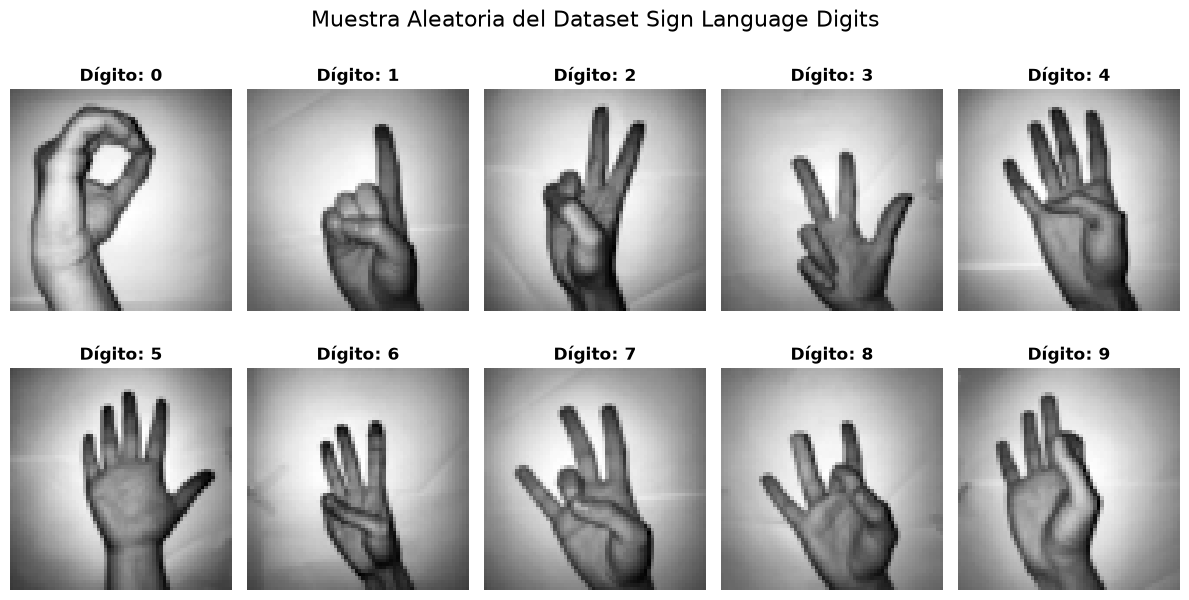

In [4]:
# 4. Muestra visual del dataset (Grilla 2x5)
plt.figure(figsize=(12, 6))

for i in range(10):
    # Encontramos el índice de la primera imagen que corresponde al dígito 'i'
    index = np.where(labels == i)[0][0]
    
    plt.subplot(2, 5, i + 1)
    # Las imágenes en este dataset suelen estar en escala de grises
    plt.imshow(X[index], cmap='gray')
    plt.title(f"Dígito: {i}", fontsize=12, fontweight='bold')
    plt.axis('off') # Ocultamos los ejes para que se vea más limpio

plt.tight_layout()
plt.suptitle("Muestra Aleatoria del Dataset Sign Language Digits", fontsize=16, y=1.05)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# 1. Añadir la dimensión del canal (Grayscale = 1 canal)
# Las CNN en Keras esperan tensores con forma (lote, alto, ancho, canales)
X_cnn = X.reshape(-1, X.shape[1], X.shape[2], 1)

# 2. Normalización de píxeles
# Llevamos los valores de intensidad al rango de 0 a 1 para estabilizar los gradientes
X_cnn = X_cnn.astype('float32')

# 3. División estratificada (80% Entrenamiento, 10% Validación, 10% Prueba)
X_train, X_temp, y_train, y_temp = train_test_split(X_cnn, Y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Muestras de Entrenamiento: {X_train.shape[0]}")
print(f"Muestras de Validación: {X_val.shape[0]}")
print(f"Muestras de Prueba: {X_test.shape[0]}")
print(f"Nueva forma del tensor de entrada: {X_train.shape}")

Muestras de Entrenamiento: 1649
Muestras de Validación: 206
Muestras de Prueba: 207
Nueva forma del tensor de entrada: (1649, 64, 64, 1)


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuración del generador de variaciones geométricas
datagen = ImageDataGenerator(
    rotation_range=15,      # Rotaciones leves de hasta 15 grados
    width_shift_range=0.1,  # Desplazamiento horizontal del 10%
    height_shift_range=0.1, # Desplazamiento vertical del 10%
    zoom_range=0.1,         # Zoom aleatorio de hasta el 10%
    horizontal_flip=False   # Falso: invertir horizontalmente podría alterar la semántica de la seña
)

# Ajustamos el generador exclusivamente con los datos de entrenamiento
datagen.fit(X_train)
print("¡Pipeline de Data Augmentation configurado exitosamente!")

¡Pipeline de Data Augmentation configurado exitosamente!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


#  HIPERPARÁMETROS 

# imagenes del dataset Sign Language Digits miden 64x64 píxeles
# tienen 1 solo canal.
FORMA_ENTRADA = (64, 64, 1) 
NUM_CLASES = 10  # Dígitos del 0 al 9


# CONSTRUCCIÓN DEL MODELO SECUENCIAL

model = Sequential(name="CNN_Lenguaje_Senas")


model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=FORMA_ENTRADA, name="Convolucion_1"))
model.add(MaxPooling2D(pool_size=(2, 2), name="Pooling_1"))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu',  name="Convolucion_2"))
model.add(MaxPooling2D(pool_size=(2, 2), name="Pooling_2"))

model.add(Flatten(name="Aplanado"))

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

c:\Users\cpuc0\taller3_ia\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Lenguaje_Senas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolucion_1 (Conv2D)          │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_1 (MaxPooling2D)        │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolucion_2 (Conv2D)          │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_2 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado (Flatten)              │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,346 (3.14 MB)

 Trainable params: 822,346 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(f" Valor máximo de los píxeles: {X_train.max()}")
print(f"Forma de las etiquetas: {y_train.shape}")

In [ ]:
import os
import datetime
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

# HIPERPARÁMETROS DE ENTRENAMIENTO

LEARNING_RATE = 0.001
EPOCHS = 50       
BATCH_SIZE = 32 


model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# Herramientas de control
directorio_actual = os.getcwd()
ruta_logs = os.path.join(directorio_actual, "logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S")+ "_mejorado_datagen")
tensorboard_callback = TensorBoard(log_dir=ruta_logs, histogram_freq=1)

early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=10,               
    restore_best_weights=True 

)

# 3. ENTRENAMIENTO 
print("Iniciando entrenamiento...")
historial = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE), 
    epochs=EPOCHS,
    validation_data=(X_val, y_val), 
    callbacks=[early_stop, tensorboard_callback]
)
print("¡Entrenamiento finalizado!")

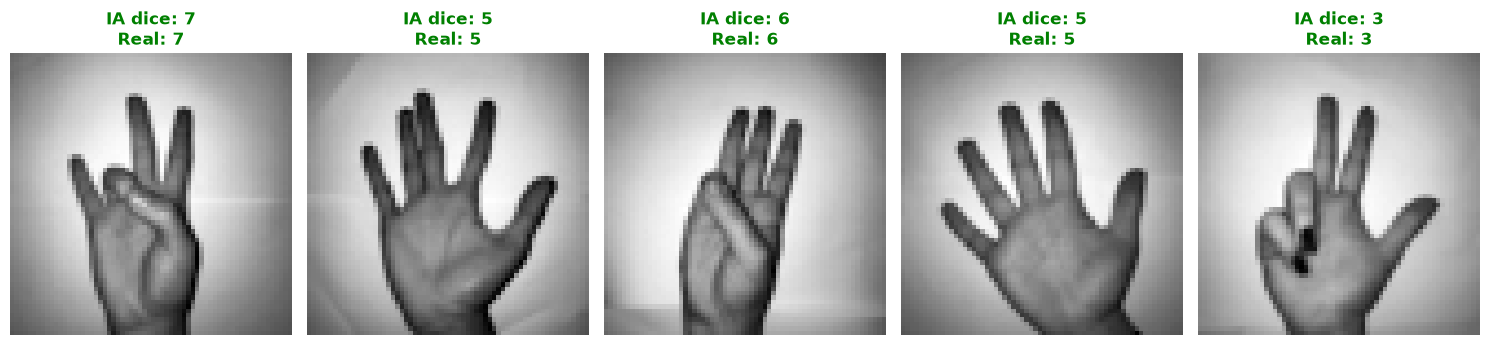

In [ ]:

#   PRUEBA VISUAL

# 5 números de lista al azar del grupo de prueba
indices_al_azar = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(15, 4))

for i, idx in enumerate(indices_al_azar):
    
    foto_pregunta = X_test[idx]
    respuesta_real = np.argmax(y_test[idx]) 
    

    foto_empaquetada = np.expand_dims(foto_pregunta, axis=0) 
    prediccion_ia = model.predict(foto_empaquetada, verbose=0)
    respuesta_ia = np.argmax(prediccion_ia) 
    
    # Dibujo de los resultados
    plt.subplot(1, 5, i + 1)

    plt.imshow(foto_pregunta.reshape(64, 64), cmap='gray') 
    
    # verde correcto, rojo fallado
    color_texto = 'green' if respuesta_real == respuesta_ia else 'red'
    
    plt.title(f"IA dice: {respuesta_ia}\nReal: {respuesta_real}", color=color_texto, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cargar la extensión de TensorBoard en el Notebook
%load_ext tensorboard

# Abrir el panel interactivo leyendo la carpeta de logs
%tensorboard --logdir logs/fit

In [ ]:

# PRUEBA FINAL CON DATOS NUNCA ANTES VISTOS

print("Evaluando el modelo definitivo con el set de Prueba (Test)...")


test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"\\nPrecisión final en datos de prueba: {test_acc * 100:.2f}%")
print(f"Pérdida final en datos de prueba: {test_loss:.4f}")

Evaluando el modelo definitivo con el set de Prueba (Test)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9275 - loss: 0.3231 
\n✅ Precisión final en datos de prueba: 92.75%
✅ Pérdida final en datos de prueba: 0.3231


Generando predicciones de prueba...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


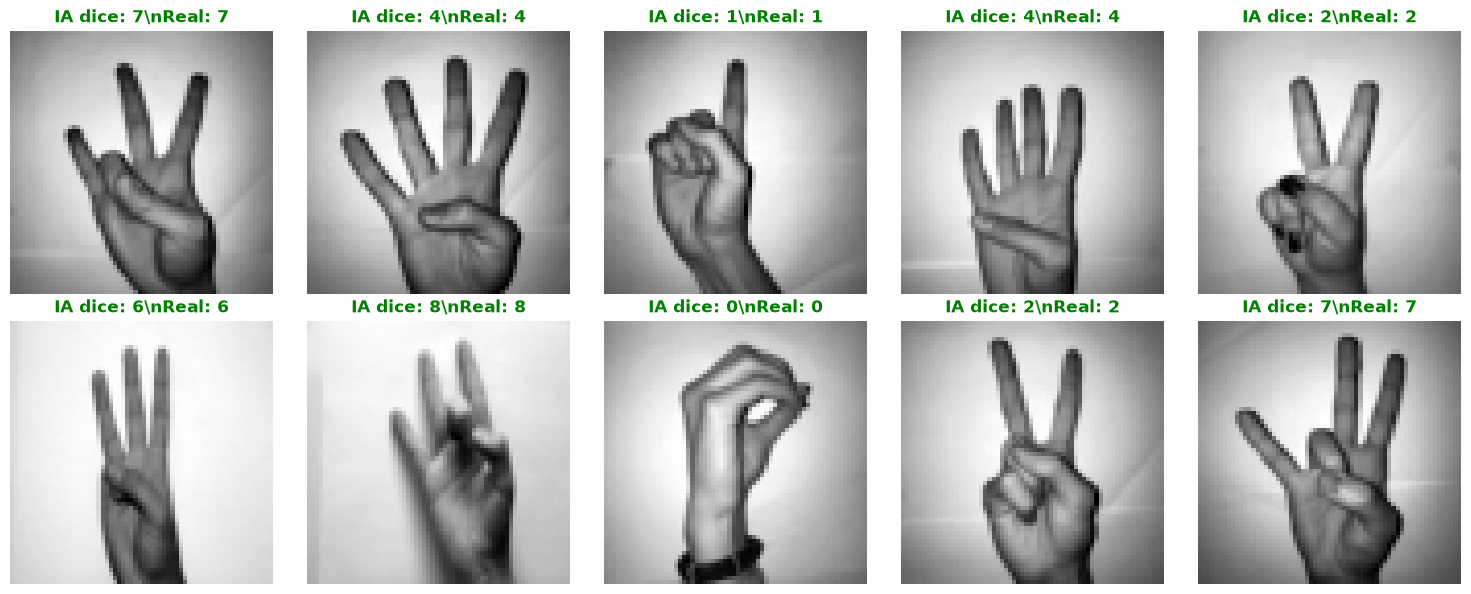

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# VISUALIZACIÓN DE PREDICCIONES (Análisis Cualitativo)

print("Generando predicciones de prueba...")

#Hacer que la IA adivine todos los datos de prueba
predicciones = model.predict(X_test)


num_filas = 2
num_columnas = 5
num_imagenes = num_filas * num_columnas


indices_aleatorios = np.random.choice(len(X_test), num_imagenes, replace=False)


plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices_aleatorios):
    plt.subplot(num_filas, num_columnas, i + 1)
    
    # Extraemos la imagen y le quitamos la dimensión extra (de 64x64x1 a 64x64) para poder dibujarla
    img = X_test[idx].reshape(64, 64)
    
    # Extraemos el número real y el que adivinó la IA usando argmax (el de mayor probabilidad)
    etiqueta_real = np.argmax(y_test[idx])
    etiqueta_predicha = np.argmax(predicciones[idx])
    
    # Si le achunta es Verde, si falla es Rojo
    color = 'green' if etiqueta_real == etiqueta_predicha else 'red'
    
    # Mostramos la foto
    plt.imshow(img, cmap='gray')
    plt.title(f"IA dice: {etiqueta_predicha}\\nReal: {etiqueta_real}", color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [54]:

# Guardado
model.save('modelo_senas_definitivo.keras')
print("modelo guardado")

modelo guardado
